# Tutorial 4 - Riparian vegetation dynamics

This tutorial demonstrates how to use the vegetation module integrated in `SARAwater`.
It covers the two complementary ecological representations available in
`sarawater.vegetation`:

- **Recruitment model**: explicit seedling establishment, plant age and mortality.
- **Camporeale model**: continuous normalized biomass dynamics.

Both models are run under the natural discharge (`Qnat`) and an illustrative
released-flow scenario (`Qrel`). The paired comparison uses exactly the same
initial vegetation state, so differences are attributable to flow alteration.

## Before starting

Install the package from the repository root in editable mode:

```bash
python -m pip install -e .
```

The example below uses a daily series for a quick tutorial. Vegetation mortality
is evaluated at the native input timestep; therefore, an hourly discharge series
is required for genuinely hourly ecological resolution.

## Import libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sarawater.reach import Reach
from sarawater.scenarios import ConstScenario
from sarawater.vegetation import VegetationConfig, compare_vegetation
from sarawater.visualization import VegetationPlotter

## I/O paths and output directory

In [2]:
OUTPUT = Path("outputs")
OUTPUT.mkdir(parents=True, exist_ok=True)
OUTPUT.resolve()

PosixPath('/mnt/data/veg_tutorial_fixed/tutorial/tutorial_4_vegetation/outputs')

## Create a didactic natural-flow series

The three-year series is deliberately constructed to produce **both successful
recruitment and mortality**, so every main recruitment output can be inspected.
Each year contains:

- a brief low-flow day at the beginning of the recruitment season;
- one broad spring flood followed by recession;
- a sustained summer baseflow that keeps groundwater accessible to only part of
  the newly exposed cohort.

This is a transparent teaching hydrograph, not a calibrated river case study.
For an application, replace this block with observed or scenario-specific flow.

In [3]:
dates = pd.date_range("2023-01-01", "2025-12-31", freq="D")

# Sustained baseflow used after the spring recession.
q_nat = np.full(len(dates), 60.0, dtype=float)

for year in sorted(np.unique(dates.year)):
    # One daily interval below baseflow. It defines a low annual stage but is
    # shorter than the default 48 h seedling drought tolerance.
    q_nat[dates == pd.Timestamp(year=year, month=4, day=1)] = 5.0

    # Broad spring flood. Its falling limb exposes the recruitment band.
    centre = pd.Timestamp(year=year, month=5, day=20)
    distance_days = (dates - centre).days.to_numpy(dtype=float)
    q_nat += 150.0 * np.exp(-0.5 * (distance_days / 12.0) ** 2)

flow = pd.DataFrame({"Date": dates, "Qnat_m3_s": q_nat})
flow.head()

,Date,Qnat_m3_s
0,2023-01-01,60.0
1,2023-01-02,60.0
2,2023-01-03,60.0
3,2023-01-04,60.0
4,2023-01-05,60.0


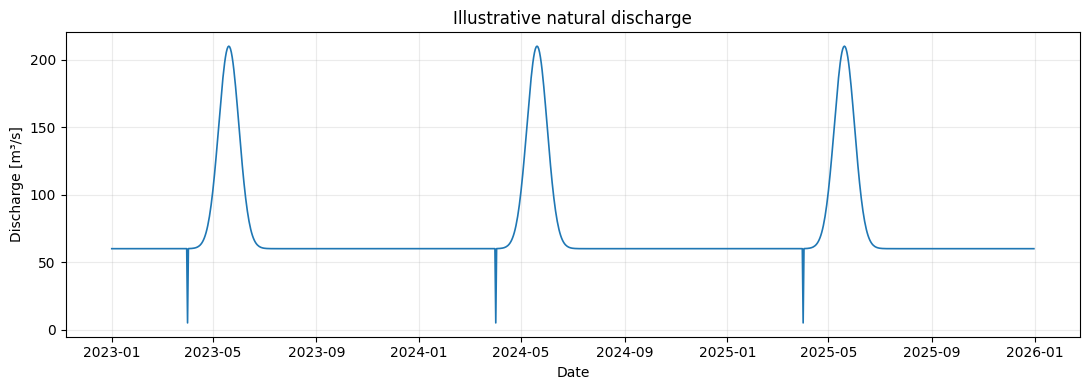

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dates, q_nat, linewidth=1.2)
ax.set(
    title="Illustrative natural discharge",
    xlabel="Date",
    ylabel="Discharge [m³/s]",
)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Create the reach, cross-section and sediment input

The vegetation module does not generate hydrology or morphology. It uses the
existing `Reach` discharge, cross-section, slope, Strickler coefficient and grain
size.

The section below contains a main channel and a broad gravel bar.
The dense transverse discretization is intentional: it provides several cells
close to the post-flood water table, so some seedlings survive while higher
seedlings experience drought mortality. Here, `30.0` is `D50` in millimetres.

In [ ]:
reach = Reach(
    "Vegetation tutorial reach",
    dates.to_pydatetime().tolist(),
    q_nat,
    15.0,
)

# Compound cross-section with a broad recruitment surface.
y = np.linspace(0.0, 100.0, 401)
control_y = np.array([0, 15, 28, 35, 42, 50, 58, 82, 90, 100], dtype=float)
control_z = np.array([5.0, 3.0, 1.0, 0.5, 0.8, 1.6, 2.3, 2.5, 3.8, 5.0])
z = np.interp(y, control_y, control_z)

section = pd.DataFrame({"y [m]": y, "z [m]": z})
reach.add_cross_section_geometry(
    slope=0.002,
    ks=30.0,
    section=section,
)
reach.add_grain_size_distribution(30.0)

section.head()

,y [m],z [m]
0,0.00,5.000000
1,0.25,4.966667
2,0.50,4.933333
3,0.75,4.900000
4,1.00,4.866667


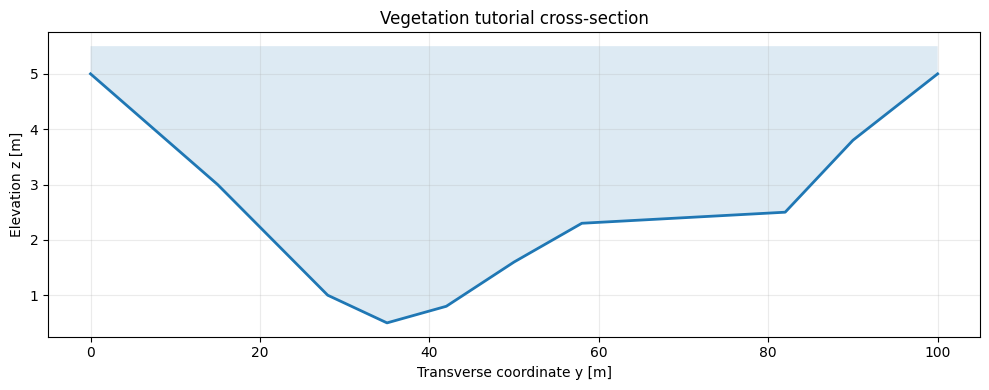

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y, z, linewidth=2)
ax.fill_between(y, z, z.max() + 0.5, alpha=0.15)
ax.set(
    title="Vegetation tutorial cross-section",
    xlabel="Transverse coordinate y [m]",
    ylabel="Elevation z [m]",
)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Add an illustrative released-flow scenario

`ConstScenario` applies a monthly released-flow constraint. This tutorial uses a
constant value of 25 m³/s in every month only to illustrate the natural-versus-
altered workflow.

In [7]:
released = ConstScenario(
    "Qrel",
    "Illustrative released-flow scenario",
    reach,
    [25.0] * 12,
)
reach.add_scenario(released)
released.compute_Qrel()

flow["Qrel_m3_s"] = released.Qrel
flow.head()

,Date,Qnat_m3_s,Qrel_m3_s
0,2023-01-01,60.0,45.0
1,2023-01-02,60.0,45.0
2,2023-01-03,60.0,45.0
3,2023-01-04,60.0,45.0
4,2023-01-05,60.0,45.0


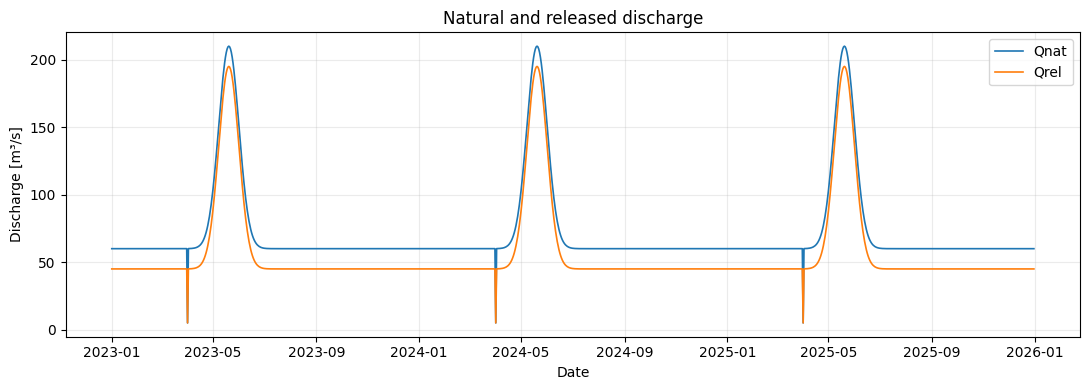

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dates, reach.Qnat, label="Qnat", linewidth=1.2)
ax.plot(dates, released.Qrel, label="Qrel", linewidth=1.2)
ax.set(
    title="Natural and released discharge",
    xlabel="Date",
    ylabel="Discharge [m³/s]",
)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Configure the vegetation models

The same configuration is shared by recruitment and Camporeale simulations.
All four process-based mortality switches remain active. The non-zero recruitment
therefore comes from the forcing and cross-section design, not from disabling
mortality.

`rating_curve` hydraulics is recommended for exploration because the hydraulic
solution is precomputed over a set of discharge values and interpolated through
time. Use `hydraulic_method="exact"` for a full hydraulic solve at every input
timestamp.

In [9]:
config = VegetationConfig(
    seed=1,
    initial_condition="bare",
    woo_days=80.0,
    hydraulic_method="rating_curve",
    rating_curve_points=80,
    enable_shear_mortality=True,
    enable_shields_mortality=True,
    enable_drought_mortality=True,
)

config

VegetationConfig(seed=1, initial_condition='bare', minimum_emergence_fraction=0.02, biomass_presence_threshold=0.05, woo_days=80.0, seed_dispersal_stage_tolerance_m=1e-06, season_start_month=4, season_start_day=1, season_end_month=9, season_end_day=30, recruitment_box_lower_offset_m=0.6, recruitment_box_upper_offset_m=2.0, resistance_initial_hours=1.0, resistance_max_hours=1440.0, resistance_growth_rate=0.001, adult_resistance_age_calendar_years=15.0, growing_season_days_per_year=183.0, resistance_transition_days=None, dose_reference_hours_seedling=24.0, dose_reference_hours_adult=144.0, dose_damage_exponent=1.5, damage_recovery_half_after_hours=168.0, damage_recovery_full_after_hours=720.0, enable_shear_mortality=True, enable_shields_mortality=True, shear_seedling_critical_pa=20.0, shear_adult_critical_pa=80.0, shields_critical=0.045, shields_adult_multiplier=8.0, shields_damage_rate_multiplier=0.2, enable_drought_mortality=True, drought_tolerance_hours_seedling=48.0, drought_toleranc

## Run paired natural-versus-released comparisons

`compare_vegetation` creates one shared initial vegetation realization and runs
it under `Qnat` and `Qrel`. This prevents random initial conditions from being
mistaken for an effect of flow alteration.

In [10]:
recruitment_comparison = compare_vegetation(
    reach,
    released,
    mode="recruitment",
    config=config,
)

camporeale_comparison = compare_vegetation(
    reach,
    released,
    mode="camporeale",
    config=config,
)

recruitment_nat = recruitment_comparison.natural
recruitment_rel = recruitment_comparison.altered
camporeale_nat = camporeale_comparison.natural
camporeale_rel = camporeale_comparison.altered

## Inspect concise model summaries

In [11]:
summary_table = pd.DataFrame(
    {
        "Recruitment - Qnat": recruitment_nat.summary(),
        "Recruitment - Qrel": recruitment_rel.summary(),
        "Camporeale - Qnat": camporeale_nat.summary(),
        "Camporeale - Qrel": camporeale_rel.summary(),
    }
)
summary_table

,Recruitment - Qnat,Recruitment - Qrel,Camporeale - Qnat,Camporeale - Qrel
mode,recruitment,recruitment,camporeale,camporeale
flow_name,natural,Qrel,natural,Qrel
initial_condition,bare,bare,bare,bare
habitat_cells,159,159,159,159
final_present_cells,16,0,159,159
final_presence_fraction,0.100629,0.0,1.0,1.0
final_established_cells,16,0,NaN,NaN
final_candidate_cells,0,0,NaN,NaN
final_mean_age_days,185.5625,0.0,NaN,NaN
final_mean_effective_age_days,93.5625,0.0,NaN,NaN


## Recruitment diagnostics

This teaching case should no longer collapse to zero. Under `Qnat`, some
candidates complete the 80-day establishment window and remain present at the
end, while other candidates die from anoxia or root-zone disconnection. Under
the altered flow, the final outcome can differ strongly.

The recruitment result includes annual opportunity, candidate seedlings,
effective age and exclusive mortality pathways. The table below shows the first
rows of the native-resolution diagnostics.

In [12]:
recruitment_nat.diagnostics.head()

,discharge,water_level,seedlings_created,recruits,candidate_cells,established_cells,mortality,mortality_candidate_seedlings,mortality_established,mortality_anoxia,mortality_shear,mortality_sediment,mortality_drought,anoxia_failure_cells,shear_failure_cells,sediment_failure_cells,drought_failure_cells,drought_exposed_cells,drought_damaging_cells,mean_drought_damage,mean_drought_disconnection_hours,max_drought_disconnection_hours,mean_root_depth_m,mean_water_table_depth_m,current_recession_rate_cm_day,drought_recession_multiplier,mean_drought_tolerance_hours,submerged_alive_cells,present_cells,presence_fraction,mean_age_days,mean_effective_age_days,mean_candidate_elapsed_days,mean_resistance_hours,mean_anoxia_hours,max_anoxia_hours,mean_shear_damage,mean_sediment_damage,shear_exceedance_cells,sediment_exceedance_cells,ebe1_valid,recession_mortality_coefficient_diagnostic
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01,60.0,2.474401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,True,0.0
2023-01-02,60.0,2.474401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,-0.0,1.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,True,0.0
2023-01-03,60.0,2.474401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,-0.0,1.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,True,0.0
2023-01-04,60.0,2.474401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,-0.0,1.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,True,0.0
2023-01-05,60.0,2.474401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,-0.0,1.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,True,0.0


## Plot recruitment state and age

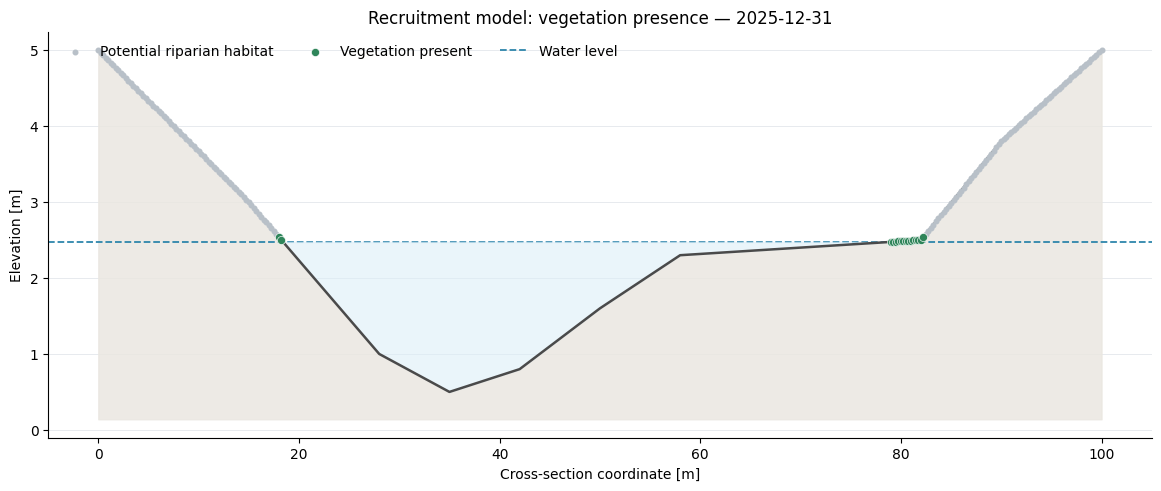

In [13]:
plotter = VegetationPlotter(OUTPUT)

fig = plotter.plot_recruitment_state(recruitment_nat)
plt.show()

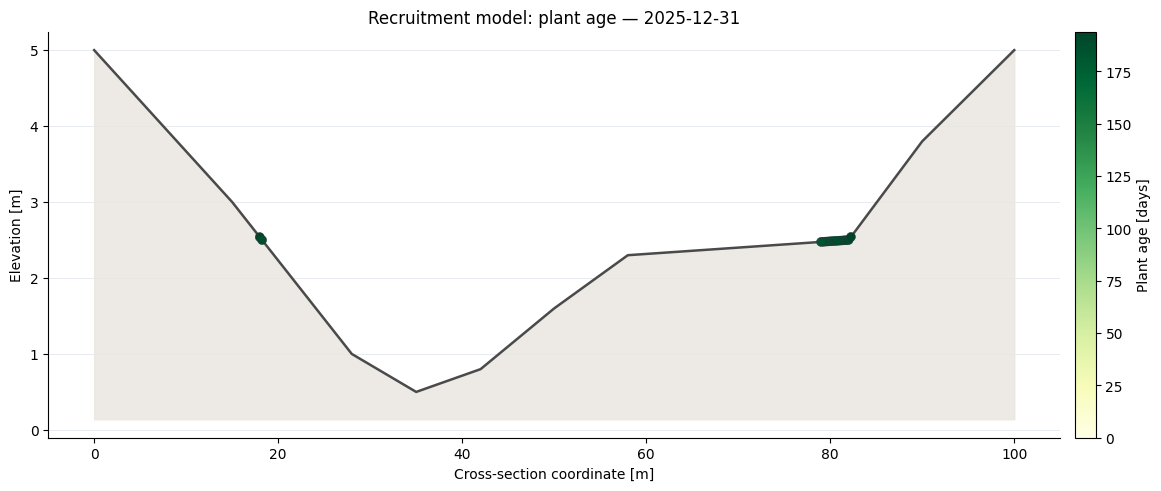

In [14]:
fig = plotter.plot_recruitment_age(recruitment_nat)
plt.show()

## Plot annual recruitment opportunity and mortality

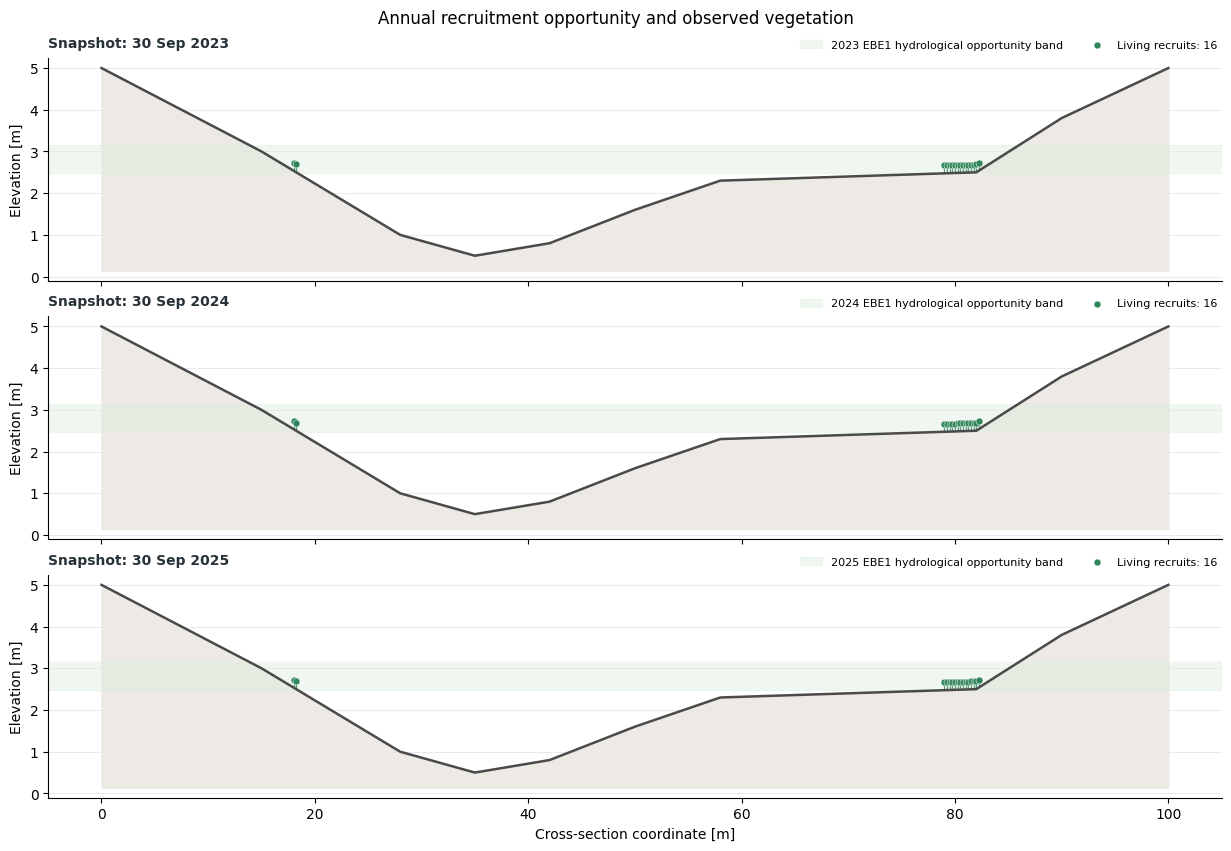

In [15]:
fig = plotter.plot_annual_recruitment_opportunity(recruitment_nat)
plt.show()

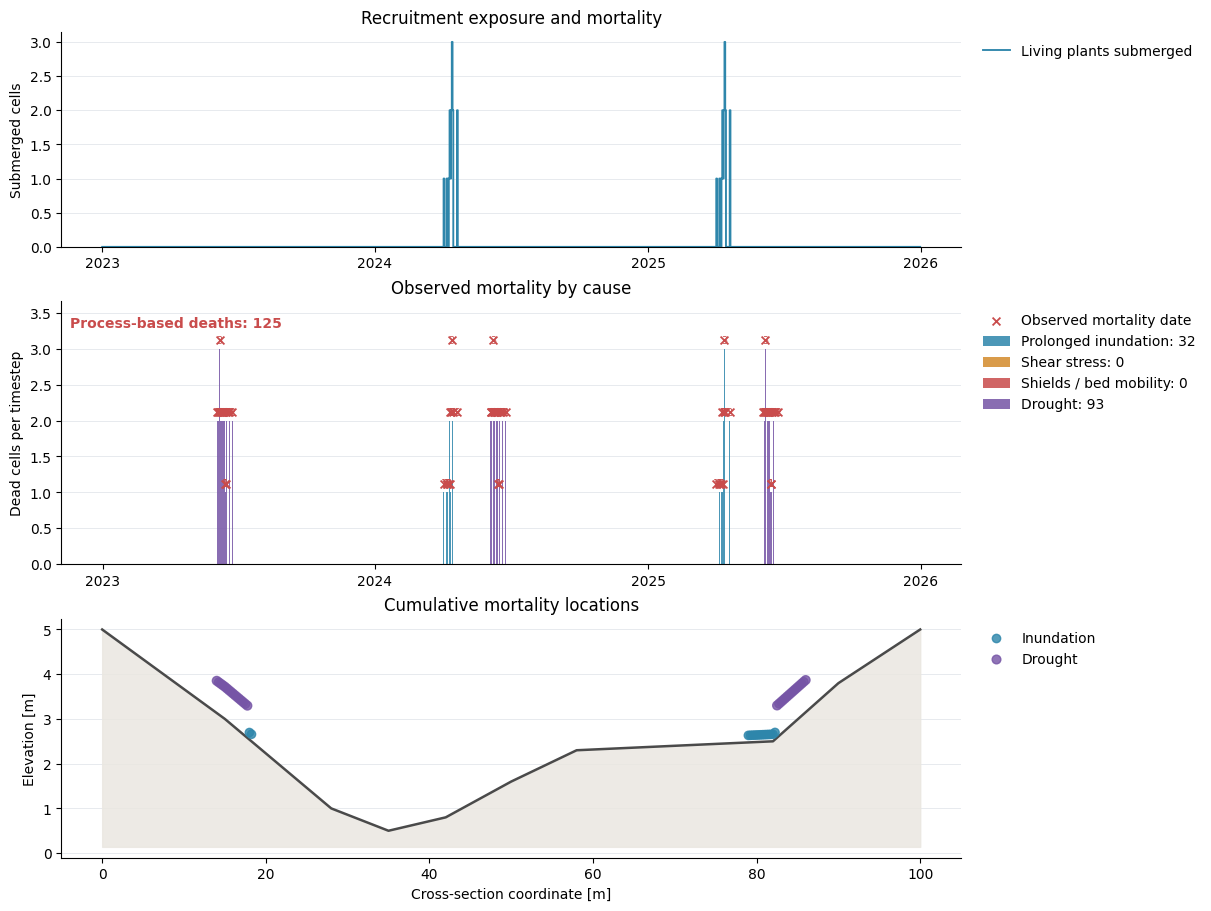

In [16]:
fig = plotter.plot_mortality(recruitment_nat)
plt.show()

## Compare final recruitment under Qnat and Qrel

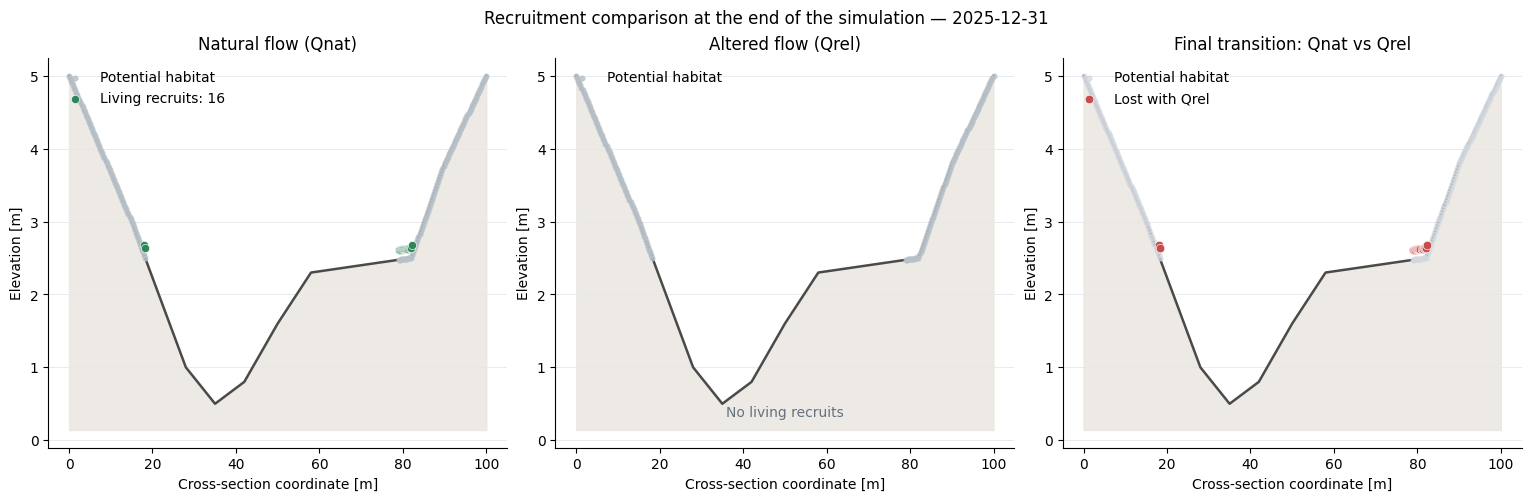

In [17]:
fig = plotter.plot_final_cross_section_comparison(recruitment_comparison)
plt.show()

## Plot Camporeale biomass

The Camporeale representation returns a continuous normalized vegetation state
instead of discrete plants and mortality causes.

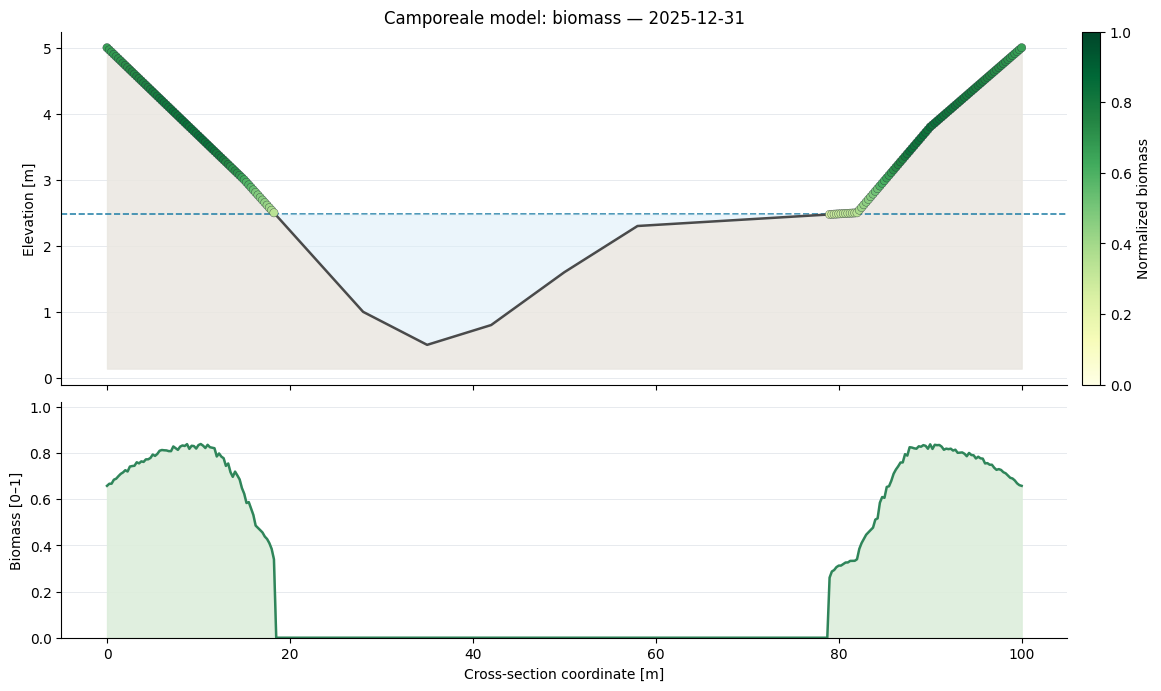

In [18]:
fig = plotter.plot_camporeale_biomass(camporeale_nat)
plt.show()

## Compare final Camporeale biomass under Qnat and Qrel

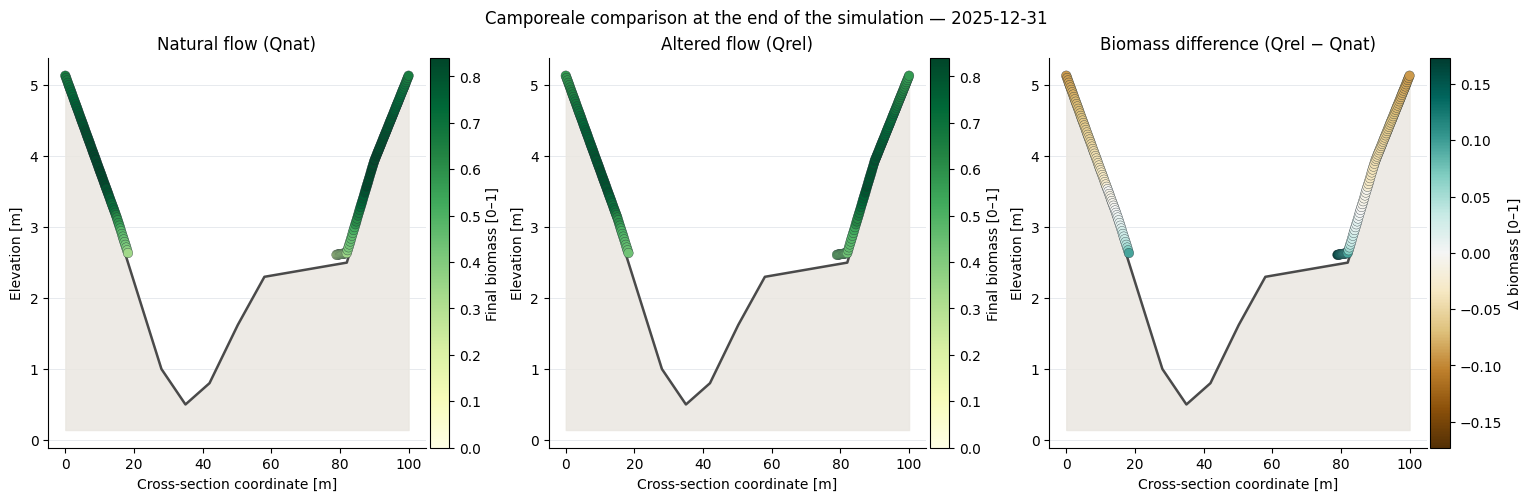

In [19]:
fig = plotter.plot_final_cross_section_comparison(camporeale_comparison)
plt.show()

## Export diagnostics, final states and standard figures

All files are written to the local `outputs` directory of this tutorial.

In [20]:
recruitment_nat.diagnostics.to_csv(
    OUTPUT / "recruitment_diagnostics_qnat.csv"
)
recruitment_rel.diagnostics.to_csv(
    OUTPUT / "recruitment_diagnostics_qrel.csv"
)
camporeale_nat.diagnostics.to_csv(
    OUTPUT / "camporeale_diagnostics_qnat.csv"
)
camporeale_rel.diagnostics.to_csv(
    OUTPUT / "camporeale_diagnostics_qrel.csv"
)

pd.DataFrame(
    {
        "y_m": recruitment_nat.y,
        "z_m": recruitment_nat.z,
        "recruitment_presence_qnat": recruitment_nat.final_presence.astype(int),
        "recruitment_presence_qrel": recruitment_rel.final_presence.astype(int),
        "recruitment_age_days_qnat": recruitment_nat.final_age_days,
        "recruitment_age_days_qrel": recruitment_rel.final_age_days,
        "recruitment_effective_age_days_qnat": recruitment_nat.final_effective_age_days,
        "recruitment_effective_age_days_qrel": recruitment_rel.final_effective_age_days,
        "camporeale_biomass_qnat": camporeale_nat.final_state,
        "camporeale_biomass_qrel": camporeale_rel.final_state,
    }
).to_csv(OUTPUT / "final_cross_section_state.csv", index=False)

figures = {
    "01_recruitment_state_qnat.png": plotter.plot_recruitment_state(recruitment_nat),
    "02_recruitment_age_qnat.png": plotter.plot_recruitment_age(recruitment_nat),
    "03_annual_recruitment_opportunity_qnat.png": (
        plotter.plot_annual_recruitment_opportunity(recruitment_nat)
    ),
    "04_mortality_qnat.png": plotter.plot_mortality(recruitment_nat),
    "05_recruitment_hydroperiod_qnat.png": (
        plotter.plot_hydroperiod_response(recruitment_nat)
    ),
    "06_camporeale_biomass_qnat.png": (
        plotter.plot_camporeale_biomass(camporeale_nat)
    ),
    "07_camporeale_hydroperiod_qnat.png": (
        plotter.plot_hydroperiod_response(camporeale_nat)
    ),
    "08_recruitment_qnat_vs_qrel.png": (
        plotter.plot_final_cross_section_comparison(recruitment_comparison)
    ),
    "09_camporeale_qnat_vs_qrel.png": (
        plotter.plot_final_cross_section_comparison(camporeale_comparison)
    ),
}

for filename, figure in figures.items():
    figure.savefig(OUTPUT / filename, dpi=180, bbox_inches="tight")
    plt.close(figure)

sorted(path.name for path in OUTPUT.iterdir())

['01_recruitment_state_qnat.png',
 '02_recruitment_age_qnat.png',
 '03_annual_recruitment_opportunity_qnat.png',
 '04_mortality_qnat.png',
 '05_recruitment_hydroperiod_qnat.png',
 '06_camporeale_biomass_qnat.png',
 '07_camporeale_hydroperiod_qnat.png',
 '08_recruitment_qnat_vs_qrel.png',
 '09_camporeale_qnat_vs_qrel.png',
 'camporeale_diagnostics_qnat.csv',
 'camporeale_diagnostics_qrel.csv',
 'final_cross_section_state.csv',
 'recruitment_diagnostics_qnat.csv',
 'recruitment_diagnostics_qrel.csv']

## Interpretation and next steps

This tutorial is designed to exercise the complete API and to return a mixed
recruitment outcome: deposition, establishment, survival and mortality are all
visible. The assumptions and values needed for the analysis, must be calibrated for each case study,
based on main species specific biological traits. 

For a scientific application, replace the teaching inputs with:

1. observed or scenario-specific discharge at the desired temporal resolution;
2. a measured cross-section with slope and roughness;
3. an appropriate `D50` or grain-size distribution;
4. root, drought and mechanical parameters justified for the target species and
   river setting.

The main reusable entry points are:

- `compare_vegetation(...)` for a fair `Qnat`–`Qrel` comparison;
- `run_reach_vegetation(...)` for natural flow only;
- `run_scenario_vegetation(...)` for one released-flow scenario;
- `run_full_vegetation_analysis(...)` for multiple initial conditions, modes and scenarios.